# PS1-6 压力传感器组 — 联合分析
Hydraulic Systems Dataset | 100 Hz 采样 | 2205 周期 × 6000 点/周期

**策略**: 先提取特征降维 (6000D→29D)，再做可视化。逐个传感器加载，避免内存溢出。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fft, signal, stats as sp_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import os, gc, sys, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

DATA_DIR = r'd:/for HS/dataset'
print('Libraries loaded.')

Libraries loaded.


## 模块 1：数据概览
轻量加载 — 只看元数据，不画图

In [2]:
# 加载 profile
profile = pd.read_csv(os.path.join(DATA_DIR, 'profile.txt'), sep='\t', header=None)
profile.columns = ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator', 'Stable']

# 文件大小
ps_names = [f'PS{i}' for i in range(1, 7)]
print(f'Profile: {profile.shape[0]} cycles × {profile.shape[1]} labels')
print()
for name in ps_names:
    fp = os.path.join(DATA_DIR, f'{name}.txt')
    size_mb = os.path.getsize(fp) / 1024**2
    print(f'  {name}.txt: {size_mb:.0f} MB')

# 加载 PS1 看基本信息后立即释放
ps1 = pd.read_csv(os.path.join(DATA_DIR, 'PS1.txt'), sep='\t', header=None)
print(f'\nPS1 shape: {ps1.shape[0]} cycles × {ps1.shape[1]} points/cycle')
print(f'PS1 global range: [{ps1.values.min():.2f}, {ps1.values.max():.2f}] bar')
print(f'PS1 per-cycle mean range: [{ps1.mean(axis=1).min():.2f}, {ps1.mean(axis=1).max():.2f}] bar')
del ps1; gc.collect()

Profile: 2205 cycles × 5 labels

  PS1.txt: 87 MB
  PS2.txt: 79 MB
  PS3.txt: 67 MB
  PS4.txt: 45 MB
  PS5.txt: 74 MB
  PS6.txt: 74 MB



PS1 shape: 2205 cycles × 6000 points/cycle
PS1 global range: [133.13, 191.92] bar
PS1 per-cycle mean range: [155.39, 180.92] bar


10

## 模块 2：特征工程 (6000D → 29D)
- 时域统计量 × 10
- 6 段分段均值 + 标准差 × 12
- 频域特征（主频 + 3 频带能量占比）× 4
- 峰值特征 × 3

In [3]:
def extract_features(row, fs=100):
    """Extract 29 features from one 6000-point pressure cycle."""
    x = row.values if hasattr(row, 'values') else np.asarray(row, dtype=np.float64)
    n = len(x)
    feats = {}
    
    # ── Time-domain (10) ──
    feats['mean']   = np.mean(x)
    feats['std']    = np.std(x)
    feats['max']    = np.max(x)
    feats['min']    = np.min(x)
    feats['range']  = feats['max'] - feats['min']
    feats['rms']    = np.sqrt(np.mean(x**2))
    feats['crest']  = np.max(np.abs(x)) / feats['rms'] if feats['rms'] > 0 else 0
    feats['skew']   = sp_stats.skew(x)
    feats['kurt']   = sp_stats.kurtosis(x)
    feats['median'] = np.median(x)
    
    # ── 6-segment stats (12) ──
    seg_len = n // 6  # 1000 points = 10s
    for s in range(6):
        seg = x[s*seg_len:(s+1)*seg_len]
        feats[f'seg{s+1}_mean'] = np.mean(seg)
        feats[f'seg{s+1}_std']  = np.std(seg)
    
    # ── Frequency domain (4) ──
    yf = fft.fft(x)
    xf = fft.fftfreq(n, d=1/fs)
    half = n // 2
    xf_half = xf[:half]  # only positive frequencies
    amp = np.abs(yf[:half]) / n * 2
    
    dom_idx = np.argmax(amp[1:]) + 1  # skip DC
    feats['dom_freq'] = xf_half[dom_idx]
    feats['dom_amp']  = amp[dom_idx]
    
    total_power = np.sum(amp**2)
    if total_power > 0:
        feats['lf_ratio'] = np.sum(amp[(xf_half>=0.1)&(xf_half<5)]**2) / total_power
        feats['mf_ratio'] = np.sum(amp[(xf_half>=5)&(xf_half<20)]**2) / total_power
        feats['hf_ratio'] = np.sum(amp[(xf_half>=20)&(xf_half<=50)]**2) / total_power
    else:
        feats['lf_ratio'] = feats['mf_ratio'] = feats['hf_ratio'] = 0.0
    
    # ── Peak features (3) ──
    prominence = max(0.05 * np.std(x), 1e-6)
    peaks, _ = signal.find_peaks(x, distance=50, prominence=prominence)
    feats['n_peaks'] = len(peaks)
    feats['peak_mean_h'] = np.mean(x[peaks]) if len(peaks) > 0 else 0.0
    feats['peak_mean_gap'] = np.mean(np.diff(peaks)) if len(peaks) > 1 else 0.0
    
    return pd.Series(feats)

print('extract_features() defined.')

extract_features() defined.


In [4]:
# 逐个处理 PS1-6，提取特征并保存降采样曲线
all_features = {}         # {sensor_name: DataFrame(2205, 29)}
downsampled_curves = {}   # {sensor_name: {fault: {state: {'mean':..., 'std':...}}}}}

target_config = {
    'Cooler':       [3, 20, 100],
    'Valve':        [73, 80, 90, 100],
    'Pump_Leakage': [0, 1, 2],
    'Accumulator':  [90, 100, 115, 130],
}

fault_labels = {
    'Cooler':       {3:'失效3%', 20:'降低20%', 100:'正常100%'},
    'Valve':        {73:'近失效73%', 80:'严重滞后80%', 90:'轻微滞后90%', 100:'正常100%'},
    'Pump_Leakage': {0:'无泄漏', 1:'轻微泄漏', 2:'严重泄漏'},
    'Accumulator':  {90:'近失效90bar', 100:'严重降压100', 115:'轻微降压115', 130:'正常130bar'},
}

for i in range(1, 7):
    name = f'PS{i}'
    print(f'\n{"="*55}\nProcessing {name}...')
    
    # Load
    df = pd.read_csv(os.path.join(DATA_DIR, f'{name}.txt'), sep='\t', header=None)
    print(f'  Shape: {df.shape}')
    
    # Extract features
    print(f'  Extracting features (FFT + peaks + stats)...')
    feats = df.apply(extract_features, axis=1)
    all_features[name] = feats
    nf = feats.shape[1]
    print(f'  → {nf} features extracted')
    
    # Downsampled curves (6000 → 60, second-level means)
    ds_curves = {}
    for fault_col, states in target_config.items():
        ds_curves[fault_col] = {}
        for state in states:
            mask = profile[fault_col] == state
            if mask.sum() > 0:
                raw = df[mask].values.astype(np.float64)  # (n_cycles, 6000)
                n_cycles = raw.shape[0]
                # Reshape: (n, 60, 100) then mean over 100-pt windows
                down = raw.reshape(n_cycles, 60, 100).mean(axis=2)  # (n_cycles, 60)
                ds_curves[fault_col][state] = {
                    'mean': down.mean(axis=0),
                    'std':  down.std(axis=0)
                }
    downsampled_curves[name] = ds_curves
    
    # Free memory
    del df; gc.collect()
    print(f'  Done {name}.')

print(f'\nAll sensors processed.')
for name, feats in all_features.items():
    print(f'  {name}: {feats.shape[0]} cycles × {feats.shape[1]} features')


Processing PS1...


  Shape: (2205, 6000)
  Extracting features (FFT + peaks + stats)...


  → 30 features extracted


  Done PS1.

Processing PS2...


  Shape: (2205, 6000)
  Extracting features (FFT + peaks + stats)...


...

  → 30 features extracted


  Done PS5.

Processing PS6...


  Shape: (2205, 6000)
  Extracting features (FFT + peaks + stats)...


  → 30 features extracted


  Done PS6.

All sensors processed.
  PS1: 2205 cycles × 30 features
  PS2: 2205 cycles × 30 features
  PS3: 2205 cycles × 30 features
  PS4: 2205 cycles × 30 features
  PS5: 2205 cycles × 30 features
  PS6: 2205 cycles × 30 features


## 模块 3：单传感器故障分类排名
Random Forest 5折CV × 4 故障标签 → 6×4 F1 热力图

In [5]:
# 对每个 PS × 每个故障标签做 5 折 CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}  # {sensor: {fault: f1_mean}}

for name, feats in all_features.items():
    results[name] = {}
    for fault_col, classes in target_config.items():
        valid_mask = profile[fault_col].isin(classes)
        X_sub = feats[valid_mask].values
        y_raw = profile[fault_col].values[valid_mask]
        le = LabelEncoder()
        y_enc = le.fit_transform(y_raw)
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        scores = cross_val_score(rf, X_sub, y_enc, cv=cv, scoring='f1_weighted')
        results[name][fault_col] = scores.mean()

# Print table
print('PS1-6 Classification F1 (5-fold CV, Random Forest):')
print(f'{"Sensor":<8}', end='')
for t in target_config:
    print(f'{t:<16}', end='')
print()
print('-' * 72)
for name in [f'PS{i}' for i in range(1, 7)]:
    print(f'{name:<8}', end='')
    for t in target_config:
        print(f'{results[name][t]:.4f}           ', end='')
    print()

# Best sensor per fault
print('\nBest sensor per fault:')
best_per_fault = {}
for t in target_config:
    best = max(results, key=lambda n: results[n][t])
    best_per_fault[t] = best
    print(f'  {t:<14} → {best} (F1={results[best][t]:.4f})')

PS1-6 Classification F1 (5-fold CV, Random Forest):
Sensor  Cooler          Valve           Pump_Leakage    Accumulator     
------------------------------------------------------------------------
PS1     0.9932           0.9932           0.9818           0.9823           
PS2     0.9914           0.9991           0.9754           0.9468           
PS3     0.9850           0.9762           0.9623           0.9545           
PS4     0.6479           0.4543           0.5969           0.5056           
PS5     0.9873           0.5959           0.8182           0.8592           
PS6     0.9868           0.5974           0.7934           0.8580           

Best sensor per fault:
  Cooler         → PS1 (F1=0.9932)
  Valve          → PS2 (F1=0.9991)
  Pump_Leakage   → PS1 (F1=0.9818)
  Accumulator    → PS1 (F1=0.9823)


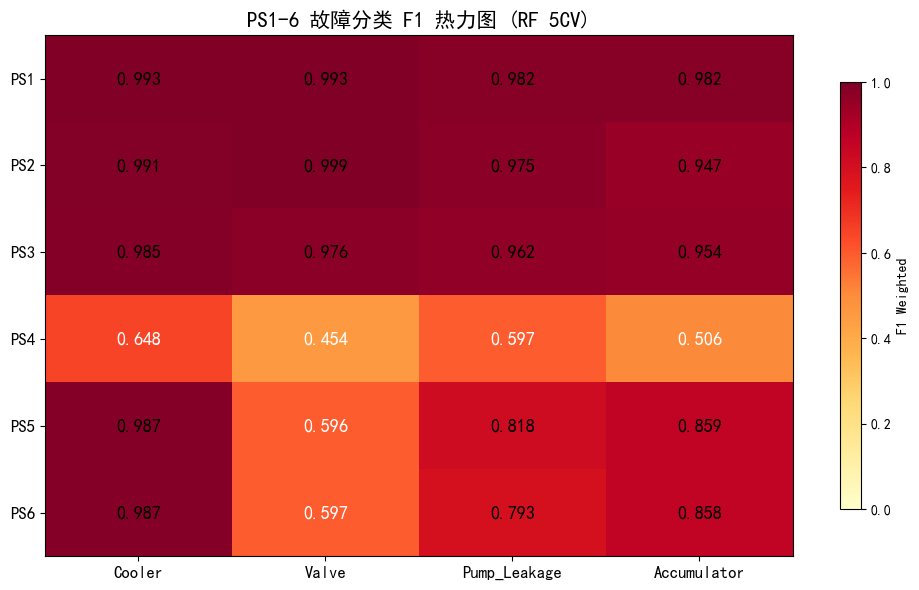

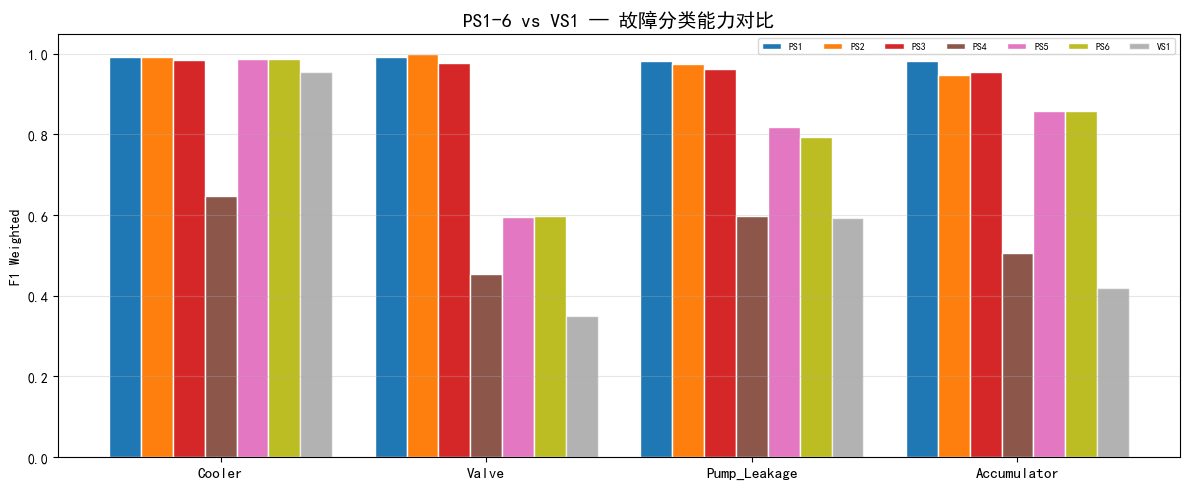

In [6]:
# 热力图
f1_df = pd.DataFrame(results).T
f1_df = f1_df[list(target_config.keys())]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(f1_df.values, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(f1_df.columns)))
ax.set_xticklabels(f1_df.columns, fontsize=12)
ax.set_yticks(range(len(f1_df.index)))
ax.set_yticklabels(f1_df.index, fontsize=12)
for i in range(len(f1_df.index)):
    for j in range(len(f1_df.columns)):
        val = f1_df.values[i, j]
        color = 'white' if val < 0.65 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=13, fontweight='bold', color=color)
ax.set_title('PS1-6 故障分类 F1 热力图 (RF 5CV)', fontsize=15)
plt.colorbar(im, shrink=0.82, label='F1 Weighted')
plt.tight_layout()
plt.show()

# VS1 comparison bar
vs1_f1 = {'Cooler': 0.956, 'Valve': 0.350, 'Pump_Leakage': 0.593, 'Accumulator': 0.419}
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(4)
w = 0.12
colors = plt.cm.tab10(np.linspace(0, 1, 7))
for idx, name in enumerate([f'PS{i}' for i in range(1, 7)]):
    f1s = [results[name][t] for t in target_config]
    ax.bar(x + idx*w, f1s, w, label=name, color=colors[idx], edgecolor='white')
vs1_vals = [vs1_f1[t] for t in target_config]
ax.bar(x + 6*w, vs1_vals, w, label='VS1', color='gray', edgecolor='white', alpha=0.6)
ax.set_xticks(x + 3*w)
ax.set_xticklabels(list(target_config.keys()), fontsize=11)
ax.set_ylabel('F1 Weighted')
ax.set_title('PS1-6 vs VS1 — 故障分类能力对比', fontsize=14)
ax.legend(fontsize=7, ncol=7)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 模块 4：降采样波形分析
6000 点 → 60 点（每秒均值），按故障状态分组。

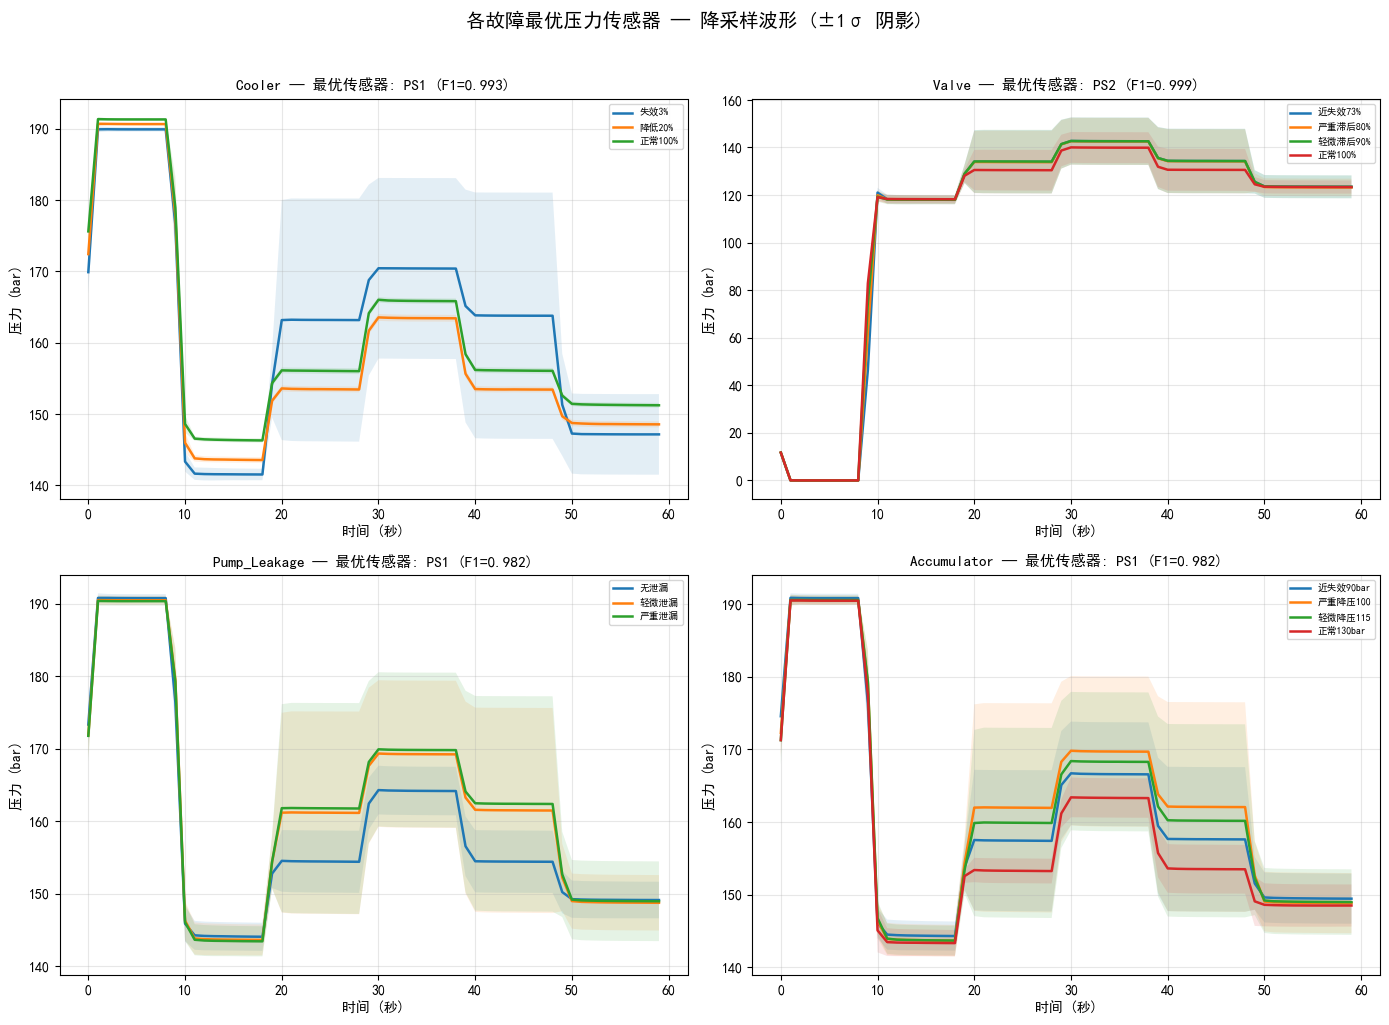

In [7]:
time = np.arange(0, 60)

# 图1: 每种故障用其最优传感器画波形
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (fault_col, best_s) in zip(axes.flat, best_per_fault.items()):
    ds = downsampled_curves[best_s][fault_col]
    for state in target_config[fault_col]:
        if state in ds:
            label = fault_labels[fault_col].get(state, str(state))
            ax.plot(time, ds[state]['mean'], linewidth=1.8, label=label)
            ax.fill_between(time,
                            ds[state]['mean']-ds[state]['std'],
                            ds[state]['mean']+ds[state]['std'],
                            alpha=0.12)
    ax.set_title(f'{fault_col} — 最优传感器: {best_s} (F1={results[best_s][fault_col]:.3f})', fontsize=11)
    ax.set_xlabel('时间 (秒)')
    ax.set_ylabel('压力 (bar)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('各故障最优压力传感器 — 降采样波形 (±1σ 阴影)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

跨传感器差异最大的故障: Valve (spread=0.545)


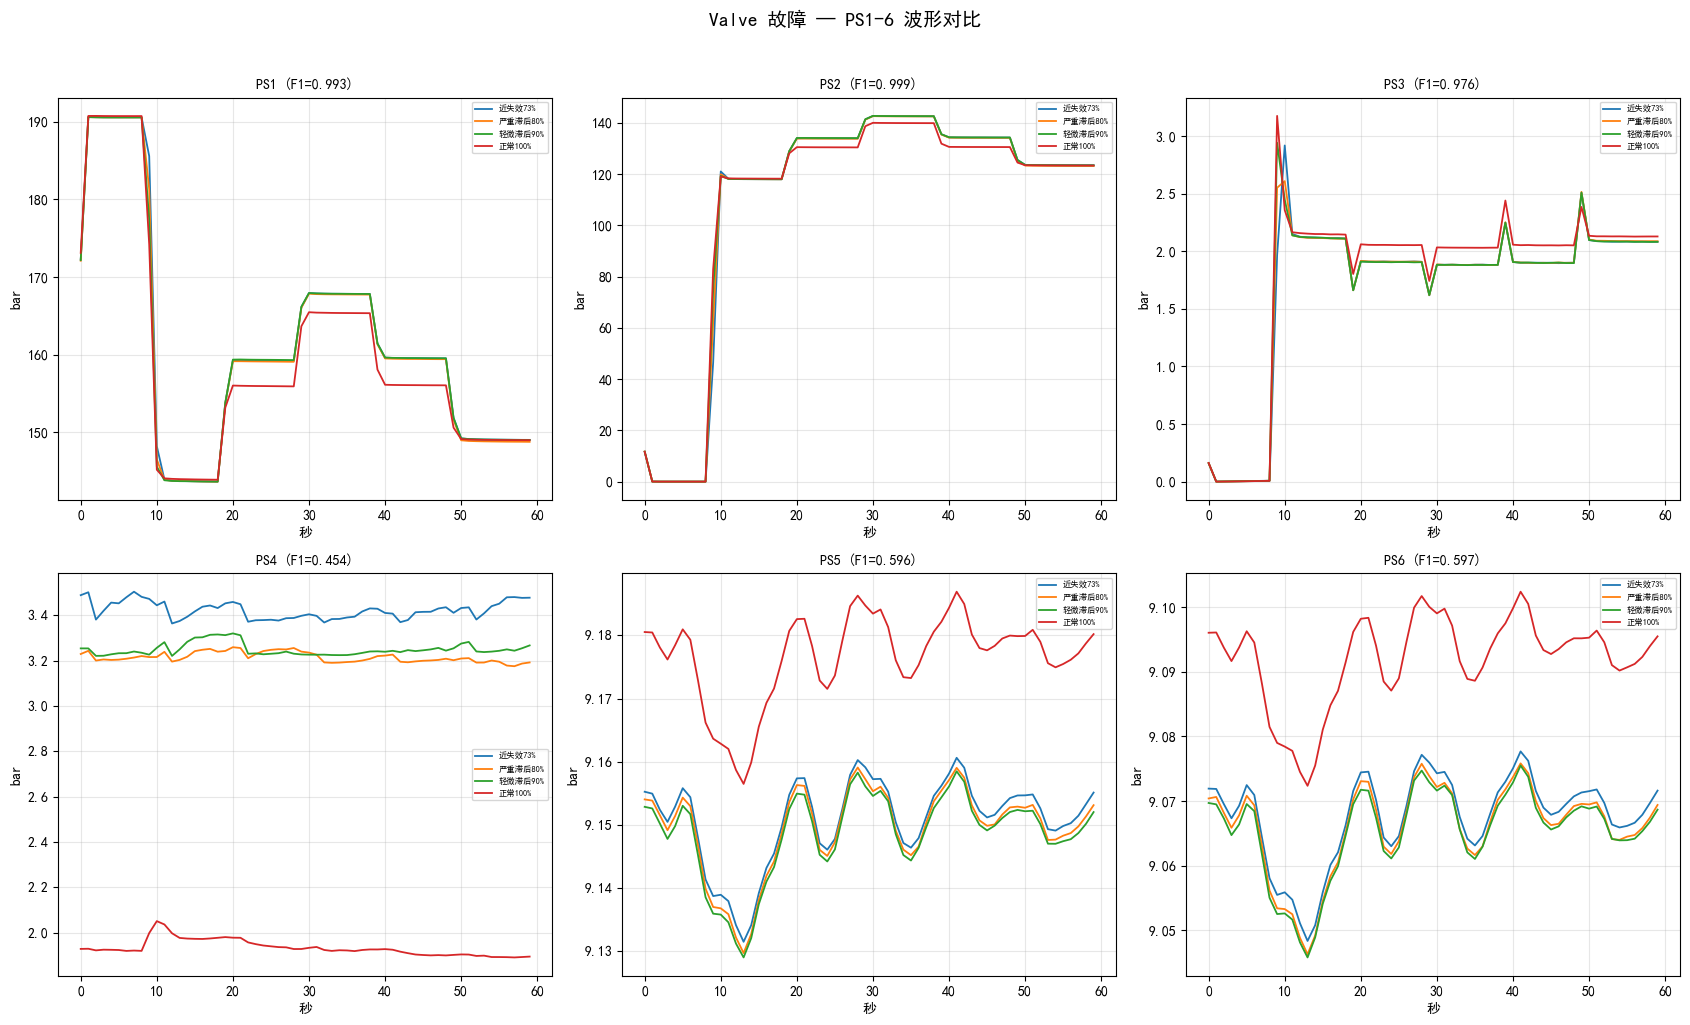

In [8]:
# 图2: 单一故障下 PS1-6 波形对比（选分类差异最大的故障）
# 找出跨 PS 分类差异最大的故障
fault_spread = {}
for t in target_config:
    vals = [results[n][t] for n in [f'PS{i}' for i in range(1, 7)]]
    fault_spread[t] = max(vals) - min(vals)
best_fault_for_viz = max(fault_spread, key=fault_spread.get)
print(f'跨传感器差异最大的故障: {best_fault_for_viz} (spread={fault_spread[best_fault_for_viz]:.3f})')

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, name in zip(axes.flat, [f'PS{i}' for i in range(1, 7)]):
    ds = downsampled_curves[name][best_fault_for_viz]
    for state in target_config[best_fault_for_viz]:
        if state in ds:
            label = fault_labels[best_fault_for_viz].get(state, str(state))
            ax.plot(time, ds[state]['mean'], linewidth=1.3, label=label)
    ax.set_title(f'{name} (F1={results[name][best_fault_for_viz]:.3f})', fontsize=10)
    ax.set_xlabel('秒')
    ax.set_ylabel('bar')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)
plt.suptitle(f'{best_fault_for_viz} 故障 — PS1-6 波形对比', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 模块 5：频域分析
100 Hz 采样 → Nyquist=50 Hz。每种故障状态取前 200 周期的平均频谱。

  Computing spectra: PS1...


  Computing spectra: PS2...


  Computing spectra: PS3...


  Computing spectra: PS4...


  Computing spectra: PS5...


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


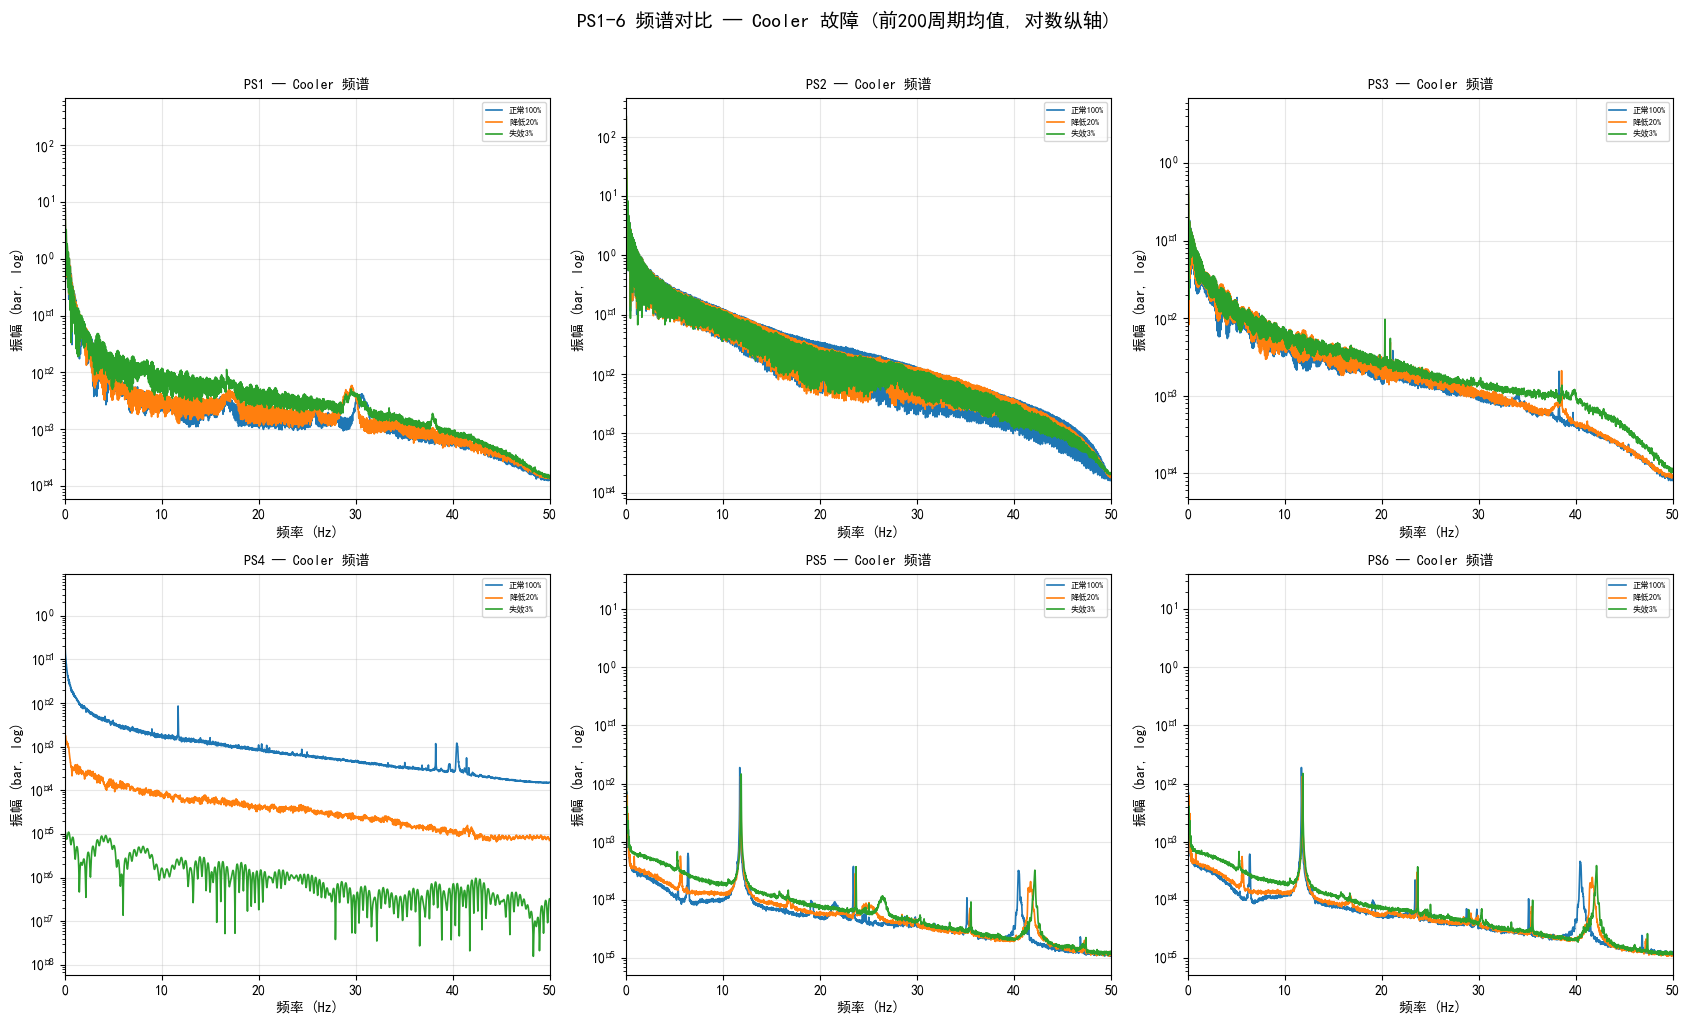

Spectra computed.


In [9]:
# Cooler 故障 — PS1-6 频谱对比
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fs = 100

for ax, name in zip(axes.flat, [f'PS{i}' for i in range(1, 7)]):
    print(f'  Computing spectra: {name}...')
    df = pd.read_csv(os.path.join(DATA_DIR, f'{name}.txt'), sep='\t', header=None)
    
    for state in [100, 20, 3]:
        mask = profile['Cooler'] == state
        if mask.sum() > 0:
            samples = df[mask].iloc[:200]  # up to 200 cycles
            spectra = []
            for idx in range(len(samples)):
                x = samples.iloc[idx].values.astype(np.float64)
                n = len(x)
                yf = fft.fft(x)
                xf = fft.fftfreq(n, d=1/fs)
                half = n // 2
                amp = np.abs(yf[:half]) / n * 2
                spectra.append(amp)
            mean_spec = np.mean(spectra, axis=0)
            label = fault_labels['Cooler'].get(state, str(state))
            ax.semilogy(xf[:half], mean_spec, linewidth=1.2, label=label)
    
    ax.set_title(f'{name} — Cooler 频谱', fontsize=10)
    ax.set_xlabel('频率 (Hz)')
    ax.set_ylabel('振幅 (bar, log)')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 50)
    del df; gc.collect()

plt.suptitle('PS1-6 频谱对比 — Cooler 故障 (前200周期均值, 对数纵轴)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('Spectra computed.')

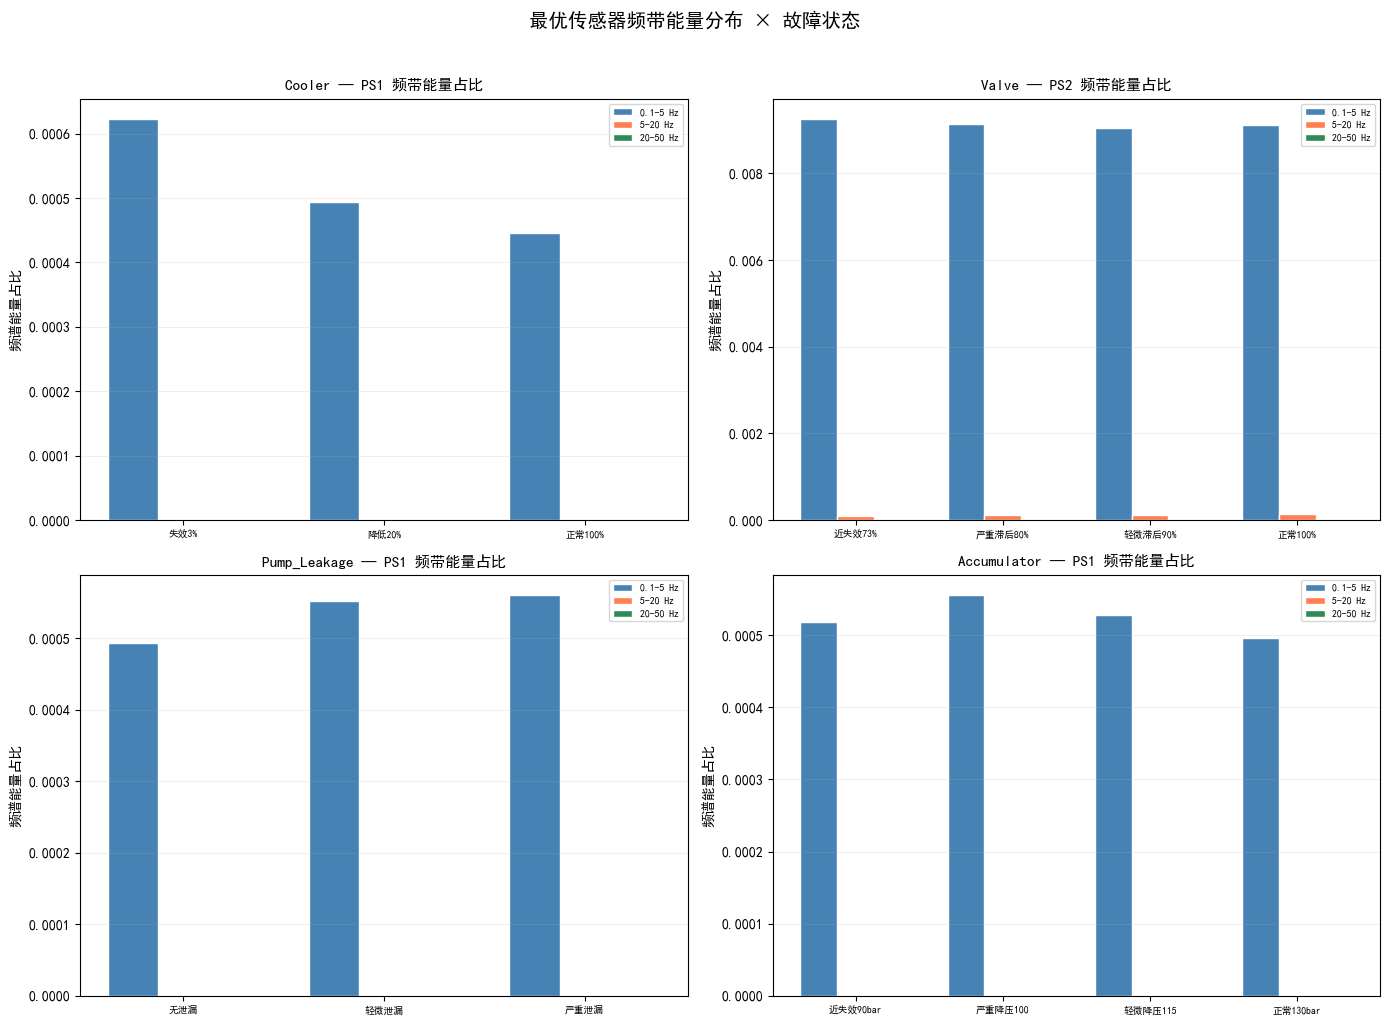

In [10]:
# 频带能量对比 — 条形图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
bands = ['lf_ratio', 'mf_ratio', 'hf_ratio']
band_labels = ['0.1-5 Hz', '5-20 Hz', '20-50 Hz']
band_colors = ['steelblue', 'coral', 'seagreen']

for ax, fault_col in zip(axes.flat, target_config):
    # Use best sensor for this fault
    best_s = best_per_fault[fault_col]
    feats = all_features[best_s].copy()
    feats['label'] = profile[fault_col].values
    
    x = np.arange(len(target_config[fault_col]))
    w = 0.25
    for bi, (band, blabel, bcolor) in enumerate(zip(bands, band_labels, band_colors)):
        means = [feats[feats['label']==s][band].mean() for s in target_config[fault_col]]
        ax.bar(x + bi*w, means, w, label=blabel, color=bcolor, edgecolor='white')
    ax.set_xticks(x + w)
    labels = [fault_labels[fault_col].get(s, str(s)) for s in target_config[fault_col]]
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_title(f'{fault_col} — {best_s} 频带能量占比', fontsize=11)
    ax.set_ylabel('频谱能量占比')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2, axis='y')
plt.suptitle('最优传感器频带能量分布 × 故障状态', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 模块 6：跨传感器综合分析
特征融合 + 相关性 + 特征重要性

Combined features: 2205 cycles × 180 dims

Multi-PS fusion vs Best single PS:
Fault            Best Single Single F1  6-PS Fusion    Gain    
------------------------------------------------------------


Cooler           PS1        0.9932      0.9941 ±0.0037  +0.0009


Valve            PS2        0.9991      0.9991 ±0.0011  +0.0000


Pump_Leakage     PS1        0.9818      0.9950 ±0.0039  +0.0132


Accumulator      PS1        0.9823      0.9936 ±0.0042  +0.0114


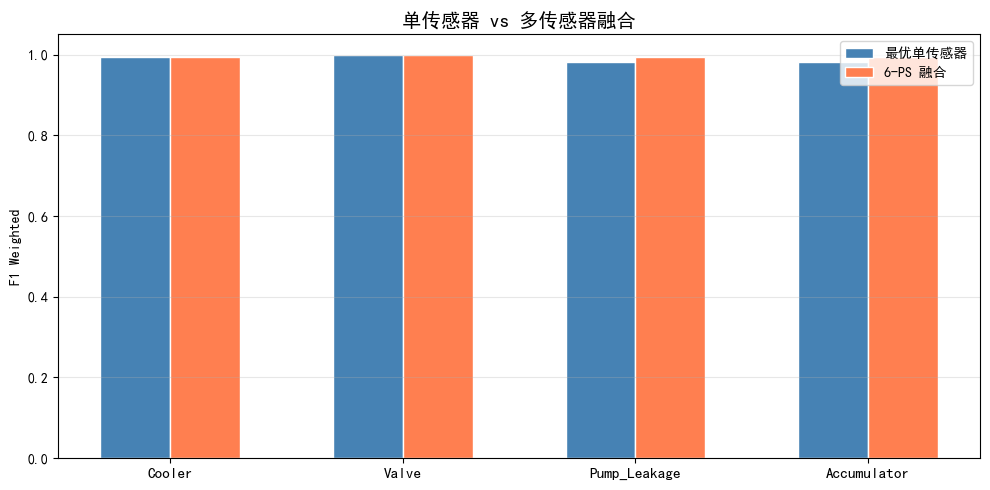

In [11]:
# 合并 6 传感器特征
ps_list = [f'PS{i}' for i in range(1, 7)]
X_all = np.hstack([all_features[name].values for name in ps_list])
print(f'Combined features: {X_all.shape[0]} cycles × {X_all.shape[1]} dims')

# 联合分类 vs 最优单传感器
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('\nMulti-PS fusion vs Best single PS:')
print(f'{"Fault":<16} {"Best Single":<10} {"Single F1":<10} {"6-PS Fusion":<14} {"Gain":<8}')
print('-' * 60)
fusion_results = {}
for fault_col, classes in target_config.items():
    valid_mask = profile[fault_col].isin(classes)
    X_sub = X_all[valid_mask]
    y_raw = profile[fault_col].values[valid_mask]
    le = LabelEncoder()
    y_enc = le.fit_transform(y_raw)
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_sub, y_enc, cv=cv, scoring='f1_weighted')
    fusion_f1 = scores.mean()
    best_s = best_per_fault[fault_col]
    best_f1 = results[best_s][fault_col]
    gain = fusion_f1 - best_f1
    fusion_results[fault_col] = fusion_f1
    print(f'{fault_col:<16} {best_s:<10} {best_f1:.4f}      {fusion_f1:.4f} ±{scores.std():.4f}  {gain:+.4f}')
    
# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
w = 0.3
best_vals = [results[best_per_fault[t]][t] for t in target_config]
fusion_vals = [fusion_results[t] for t in target_config]
ax.bar(x - w/2, best_vals, w, label='最优单传感器', color='steelblue', edgecolor='white')
ax.bar(x + w/2, fusion_vals, w, label='6-PS 融合', color='coral', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(list(target_config.keys()), fontsize=11)
ax.set_ylabel('F1 Weighted')
ax.set_title('单传感器 vs 多传感器融合', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

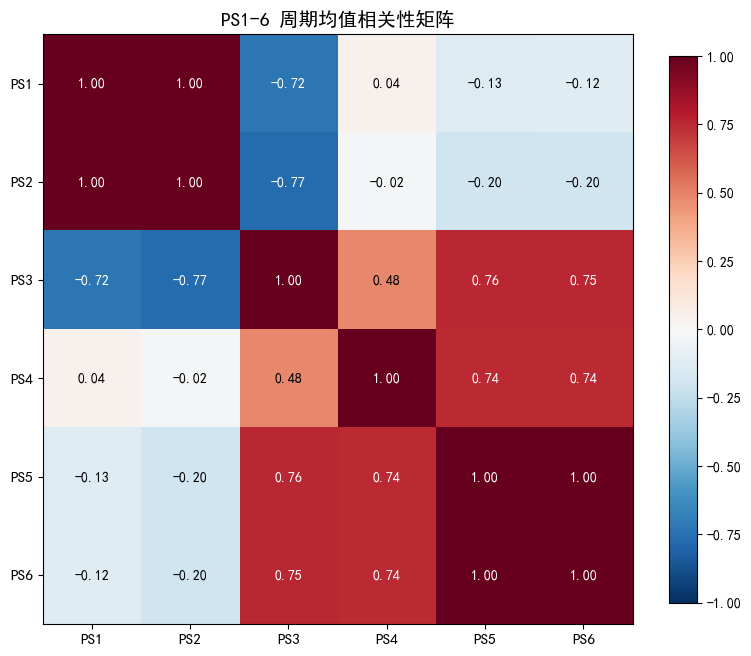

In [12]:
# PS1-6 周期均值相关性
sensor_means = pd.DataFrame({
    name: all_features[name]['mean'].values for name in ps_list
})
corr = sensor_means.corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(6))
ax.set_xticklabels(ps_list, fontsize=11)
ax.set_yticks(range(6))
ax.set_yticklabels(ps_list, fontsize=11)
for i in range(6):
    for j in range(6):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10, color=color)
ax.set_title('PS1-6 周期均值相关性矩阵', fontsize=14)
plt.colorbar(im, shrink=0.82)
plt.tight_layout()
plt.show()

Fusion-best fault: Valve (F1=0.9991)


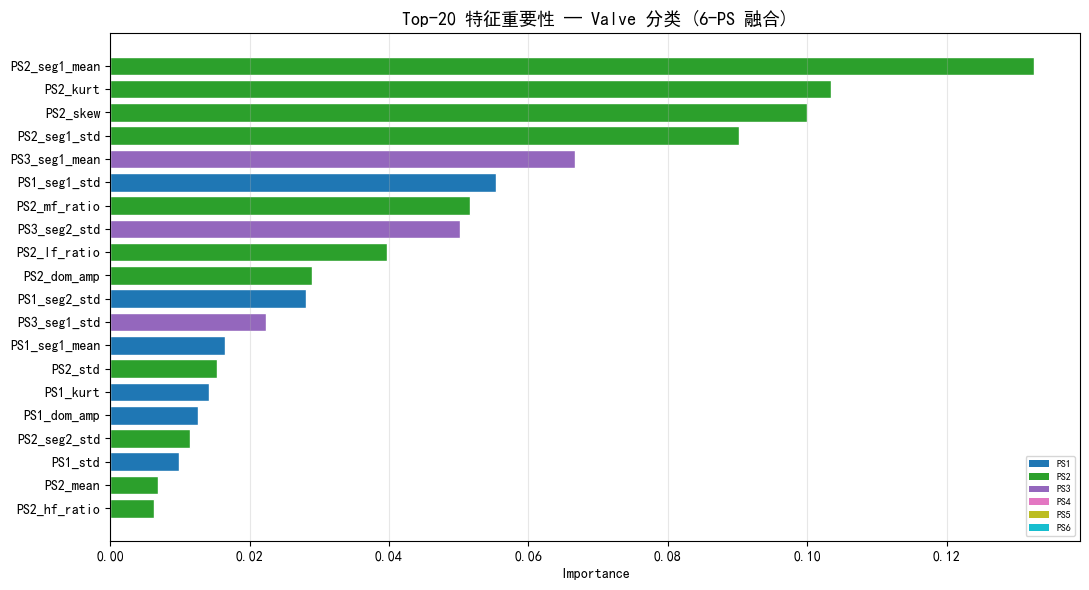

In [13]:
# 特征重要性 — 融合模型对最佳分类故障的 top-20 特征
best_fault = max(fusion_results, key=fusion_results.get)
print(f'Fusion-best fault: {best_fault} (F1={fusion_results[best_fault]:.4f})')

valid_mask = profile[best_fault].isin(target_config[best_fault])
X_sub = X_all[valid_mask]
y_raw = profile[best_fault].values[valid_mask]
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_sub, y_enc)

# Build feature names
feature_names = []
for name in ps_list:
    for col in all_features[name].columns:
        feature_names.append(f'{name}_{col}')

imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
top20 = imp.head(20)

# Color by sensor
sensor_colors = plt.cm.tab10(np.linspace(0, 1, 6))
bar_colors = []
for fname in top20.index:
    for si, sname in enumerate(ps_list):
        if fname.startswith(sname + '_'):
            bar_colors.append(sensor_colors[si])
            break

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color=bar_colors[::-1], edgecolor='white')
ax.set_title(f'Top-20 特征重要性 — {best_fault} 分类 (6-PS 融合)', fontsize=13)
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=sensor_colors[si], label=ps_list[si]) for si in range(6)]
ax.legend(handles=legend_patches, fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

## 模块 7：总结

In [14]:
print('=' * 70)
print('PS1-6 压力传感器组分析 — 总结')
print('=' * 70)
print()
print('1. 单传感器分类 F1 (5CV Random Forest):')
print(f1_df.round(4).to_string())
print()
print('2. 最优单传感器:')
for t in target_config:
    best = best_per_fault[t]
    print(f'   {t:<14} → {best} (F1={results[best][t]:.4f})')
print()
print('3. 多传感器融合收益:')
for t in target_config:
    best = best_per_fault[t]
    gain = fusion_results[t] - results[best][t]
    print(f'   {t:<14} → {results[best][t]:.4f} → {fusion_results[t]:.4f} ({gain:+.4f})')
print()
print('4. 关键发现:')
print(f'   - 最强单传感器: {max(results, key=lambda n: np.mean(list(results[n].values())))}')
print(f'   - 最好分的故障: {max(target_config, key=lambda t: max(results[n][t] for n in results))}')
worst_fault = min(target_config, key=lambda t: max(results[n][t] for n in results))
print(f'   - 最难分的故障: {worst_fault}')
print(f'   - 6传感器融合 vs 最优单传感器平均增益: {np.mean([fusion_results[t]-results[best_per_fault[t]][t] for t in target_config]):+.4f}')
print()
print('=' * 70)
print('Analysis complete.')

PS1-6 压力传感器组分析 — 总结

1. 单传感器分类 F1 (5CV Random Forest):
     Cooler   Valve  Pump_Leakage  Accumulator
PS1  0.9932  0.9932        0.9818       0.9823
PS2  0.9914  0.9991        0.9754       0.9468
PS3  0.9850  0.9762        0.9623       0.9545
PS4  0.6479  0.4543        0.5969       0.5056
PS5  0.9873  0.5959        0.8182       0.8592
PS6  0.9868  0.5974        0.7934       0.8580

2. 最优单传感器:
   Cooler         → PS1 (F1=0.9932)
   Valve          → PS2 (F1=0.9991)
   Pump_Leakage   → PS1 (F1=0.9818)
   Accumulator    → PS1 (F1=0.9823)

3. 多传感器融合收益:
   Cooler         → 0.9932 → 0.9941 (+0.0009)
   Valve          → 0.9991 → 0.9991 (+0.0000)
   Pump_Leakage   → 0.9818 → 0.9950 (+0.0132)
   Accumulator    → 0.9823 → 0.9936 (+0.0114)

4. 关键发现:
   - 最强单传感器: PS1
   - 最好分的故障: Valve
   - 最难分的故障: Pump_Leakage
   - 6传感器融合 vs 最优单传感器平均增益: +0.0064

Analysis complete.
